In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [5]:
df.dtypes

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df =df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

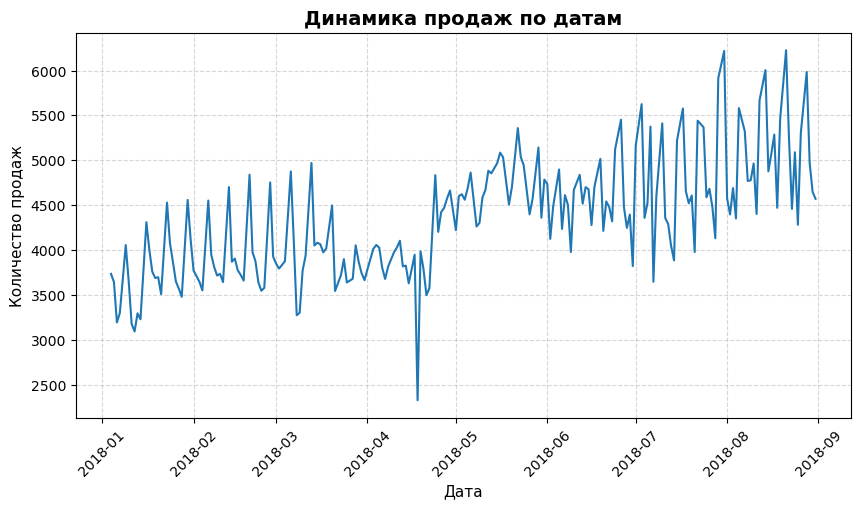

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Динамика продаж по датам', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=11)
plt.ylabel('Количество продаж', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике можно увидеть динамику продаж с января по сентябрь 2018 года. В целом видно, что продажи постепенно растут,в начале года они были около 3500,а к концу лета поднялись до 5000–6000. На протяжении всего периода отчетливо заметны частые скачки вверх и вниз, похожие на обычные всплески по выходным и спады в будни. Также выделяется сильная аномалия в середине апреля, когда продажи резко упали почти до 2300, что может быть связано с праздником или сбоем в учете. С мая колебания стали сильнее, но общий уровень продаж продолжил уверенно идти вверх, что очень хорошо.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
#1 Метод, максимальное значение:
max_outlier_index = df['Количество'].idxmax()
max_outlier_index

218822

In [10]:
outlier_row = df.loc[[max_outlier_index]]
outlier_row

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


In [11]:
#2 Метод, максимальный выброс:
Q1 = np.percentile(df['Количество'], 25)
median = np.median(df['Количество'])
Q3 = np.percentile(df['Количество'], 75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df[df['Количество'] > upper_bound]
max_outlier = outliers.loc[outliers['Количество'].idxmax()]
print(max_outlier)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [12]:
filtered = df[(df['Дата'].dt.month.isin([6, 7, 8]))&(df['Дата'].dt.weekday==2)&(df['Склад']==3)]

In [13]:
filtered

,Дата,Склад,Контрагент,Номенклатура,Количество
191165,2018-06-06,3,address_206,product_0,2
191166,2018-06-06,3,address_206,product_1,4
191167,2018-06-06,3,address_206,product_2,4
191168,2018-06-06,3,address_206,product_3,2
191169,2018-06-06,3,address_206,product_4,1
...,...,...,...,...,...
298028,2018-08-29,3,address_112,product_2,3
298029,2018-08-29,3,address_112,product_3,3
298030,2018-08-29,3,address_112,product_4,2
298031,2018-08-29,3,address_112,product_5,1


In [14]:
top_product=filtered.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False)

In [15]:
top_product.head(1)

Номенклатура
product_1    2267
Name: Количество, dtype: int64

In [16]:
print("Топовый товар:", top_product.index[0])
print("Количество продаж:", top_product.iloc[0])

Топовый товар: product_1
Количество продаж: 2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [17]:
grouped_df['Дата'].min()

Timestamp('2018-01-04 00:00:00')

In [18]:
grouped_df['Дата'].max()

Timestamp('2018-08-31 00:00:00')

In [19]:
weather = pd.read_csv("weather.csv", sep=';', skiprows=6)

In [20]:
print(weather.columns.tolist())

['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10', 'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch', 'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', "E'", 'sss']


In [21]:
weather = pd.read_csv("weather.csv", sep=';', skiprows=6, index_col=False)
print(weather.columns.tolist())
weather.head()

['Местное время в Астане', 'T', 'Po', 'P', 'Pa', 'U', 'DD', 'Ff', 'ff10', 'ff3', 'N', 'WW', 'W1', 'W2', 'Tn', 'Tx', 'Cl', 'Nh', 'H', 'Cm', 'Ch', 'VV', 'Td', 'RRR', 'tR', 'E', 'Tg', "E'", 'sss']


,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN


In [22]:
weather = weather[['Местное время в Астане', 'T']].copy()
weather.columns = ['Дата', 'T']
weather.head()

,Дата,T
0,31.08.2018 23:00,8.2
1,31.08.2018 20:00,9.6
2,31.08.2018 17:00,11.3
3,31.08.2018 14:00,12.3
4,31.08.2018 11:00,13.2


In [23]:
weather['Дата'] = pd.to_datetime(weather['Дата'], format='%d.%m.%Y %H:%M')
weather.head()

,Дата,T
0,2018-08-31 23:00:00,8.2
1,2018-08-31 20:00:00,9.6
2,2018-08-31 17:00:00,11.3
3,2018-08-31 14:00:00,12.3
4,2018-08-31 11:00:00,13.2


In [24]:
weather_daily = weather.groupby(weather['Дата'].dt.date)['T'].mean().reset_index()

In [25]:
weather_daily['Дата'] = pd.to_datetime(weather_daily['Дата'])

In [26]:
weather_daily.head()

,Дата,T
0,2018-01-04,-14.0750
1,2018-01-05,-16.8625
2,2018-01-06,-13.3000
3,2018-01-07,-12.7500
4,2018-01-08,-15.4125


In [27]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата'])

In [28]:
merged_df = pd.merge(grouped_df,weather_daily,on='Дата',how='inner')

In [29]:
merged_df.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


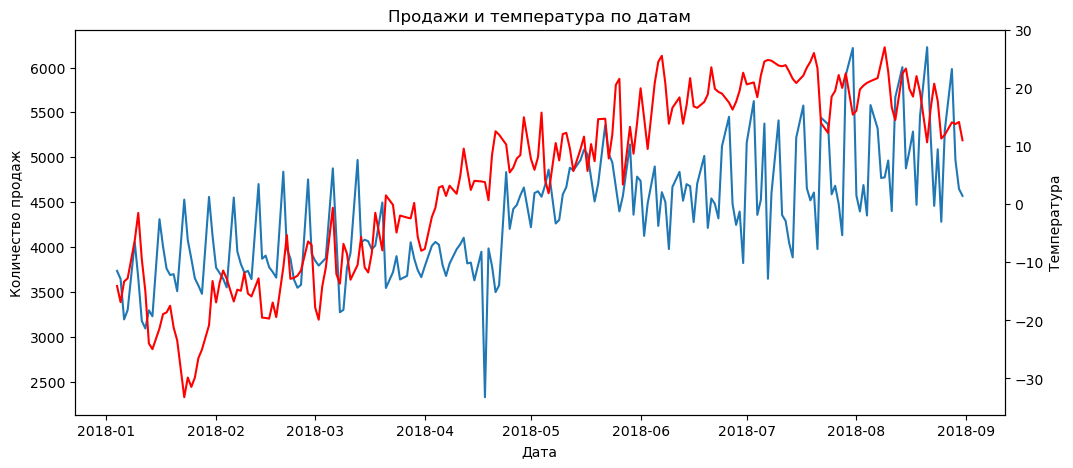

In [35]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(merged_df['Дата'], merged_df['Количество'], label='Количество продаж')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество продаж')

ax2 = ax.twinx()
ax2.plot(merged_df['Дата'], merged_df['T'], color='red', label='Температура')
ax2.set_ylabel('Температура')

plt.title('Продажи и температура по датам')
plt.show()

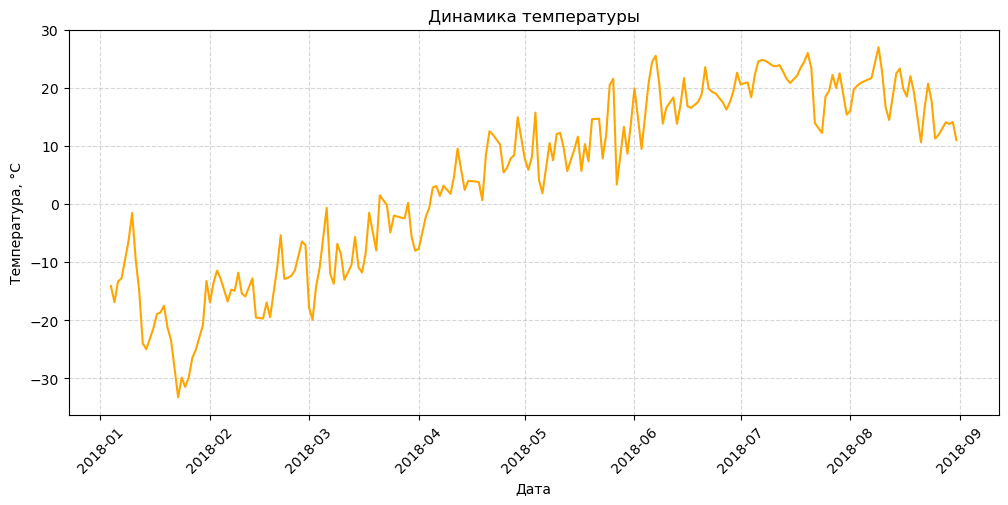

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(merged_df['Дата'], merged_df['T'], color='orange')
plt.title('Динамика температуры')
plt.xlabel('Дата')
plt.ylabel('Температура, °C')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.show()